<div style="margin-bottom: 32px;">
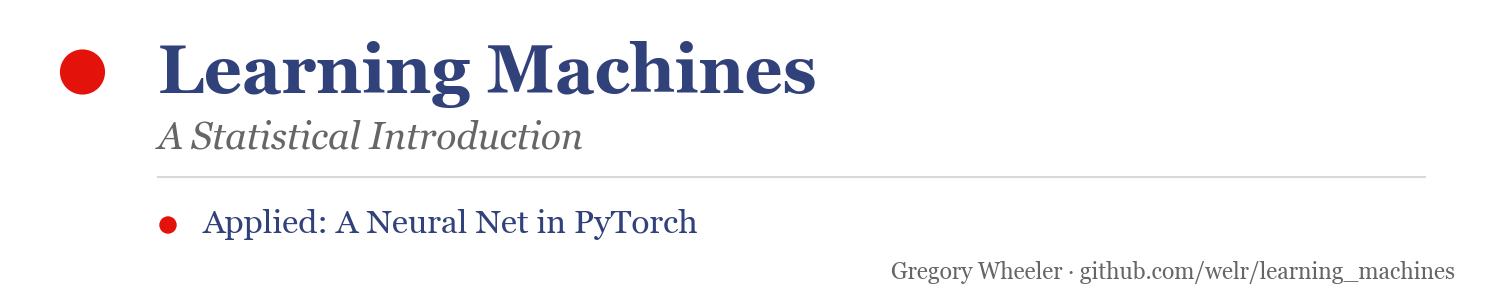
</div>


# Applied — A Neural Network in PyTorch

This is the first rung toward the book's capstone. Here you build and train a small neural network in PyTorch on a real image dataset, **Fashion-MNIST**, using a complete training loop. That loop—draw a minibatch, compute the loss, backpropagate, step the optimizer—is the same loop, unchanged in shape, that trains a convolutional network in Chapter 10 and a GPT in Chapter 12. Learn it once, here.

One cell is marked **🔧 Your turn**: the training loop itself. A reference follows, so the notebook runs end to end.

In [1]:
import warnings
warnings.filterwarnings("ignore")          # quiet a benign OpenML fetch warning
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
# Colab: fetch the plot-style helper if it isn't beside this notebook
import os as _os, urllib.request as _ur
if not _os.path.exists("mlone_theme.py"):
    _BASE = "https://raw.githubusercontent.com/welr/learning_machines/main/"
    for _f in ("mlone_theme.py", "mlone_style.mplstyle"):
        _ur.urlretrieve(_BASE + _f, _f)
import mlone_theme as mt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

plt.style.use("mlone_style.mplstyle")
mt.set_notebook_mode()                      # green companion-notebook palette
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


## The data: Fashion-MNIST

Fashion-MNIST is 70,000 grayscale images, 28×28 pixels, each a garment in one of ten classes. We flatten each image to a 784-vector, scale the pixels to $[0,1]$, and—to keep training to a few seconds on a CPU—work with a random subsample. (The first `fetch_openml` call downloads about 30 MB and caches it locally.)

In [2]:
classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

X, y = fetch_openml("Fashion-MNIST", version=1, as_frame=False, return_X_y=True)
X = (X / 255.0).astype("float32")
y = y.astype(int)

subset = np.random.permutation(len(X))[:15000]          # a CPU-friendly slice
X, y = X[subset], y[subset]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
X_tr, y_tr = torch.tensor(X_tr), torch.tensor(y_tr)
X_te, y_te = torch.tensor(X_te), torch.tensor(y_te)
print(f"{len(X_tr)} train, {len(X_te)} test images of {X.shape[1]} pixels each")

12000 train, 3000 test images of 784 pixels each


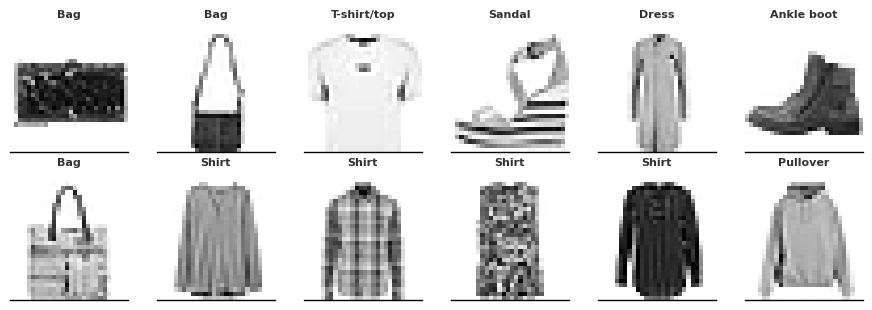

In [3]:
fig, axes = plt.subplots(2, 6, figsize=(9, 3.2))
for ax, i in zip(axes.ravel(), range(12)):
    ax.imshow(X_tr[i].reshape(28, 28), cmap="gray_r")
    ax.set_title(classes[y_tr[i]], fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

## The model

A plain feed-forward network: two hidden layers with ReLU and a little dropout, then a linear layer to ten class scores. `forward` returns the raw scores (logits); the cross-entropy loss applies the softmax internally—the same loss as logistic regression in Chapter 4, generalized to ten classes.

In [4]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)              # logits; CrossEntropyLoss applies the softmax

model = MLP().to(device)
print(f"{sum(p.numel() for p in model.parameters()) / 1e3:.0f}k parameters")

235k parameters


## Training

**🔧 Your turn.** Write the training loop. For each epoch, shuffle the training set and walk it in minibatches; for each batch, zero the gradients, compute the cross-entropy loss, call `loss.backward()`, and step the optimizer. Track the loss and the held-out accuracy as you go. This is the loop you will reuse, almost unchanged, for the convolutional network of Chapter 10 and the GPT of Chapter 12. A reference follows.

In [5]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
batch_size, epochs = 128, 12

@torch.no_grad()
def accuracy(X, Y):
    model.eval()
    preds = model(X).argmax(dim=1)
    model.train()
    return (preds == Y).float().mean().item()

history = []
for epoch in range(epochs):
    order = torch.randperm(len(X_tr))                 # reshuffle each epoch
    for i in range(0, len(X_tr), batch_size):
        batch = order[i : i + batch_size]
        logits = model(X_tr[batch])
        loss = loss_fn(logits, y_tr[batch])
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
    history.append((epoch, loss.item(), accuracy(X_te, y_te)))
    print(f"epoch {epoch + 1:2d} | train loss {loss.item():.3f} | test accuracy {history[-1][2]:.3f}")

epoch  1 | train loss 0.779 | test accuracy 0.788
epoch  2 | train loss 0.412 | test accuracy 0.826
epoch  3 | train loss 0.454 | test accuracy 0.831


epoch  4 | train loss 0.427 | test accuracy 0.838
epoch  5 | train loss 0.443 | test accuracy 0.843
epoch  6 | train loss 0.334 | test accuracy 0.847


epoch  7 | train loss 0.513 | test accuracy 0.851
epoch  8 | train loss 0.366 | test accuracy 0.863
epoch  9 | train loss 0.384 | test accuracy 0.853


epoch 10 | train loss 0.332 | test accuracy 0.859
epoch 11 | train loss 0.301 | test accuracy 0.859
epoch 12 | train loss 0.343 | test accuracy 0.860


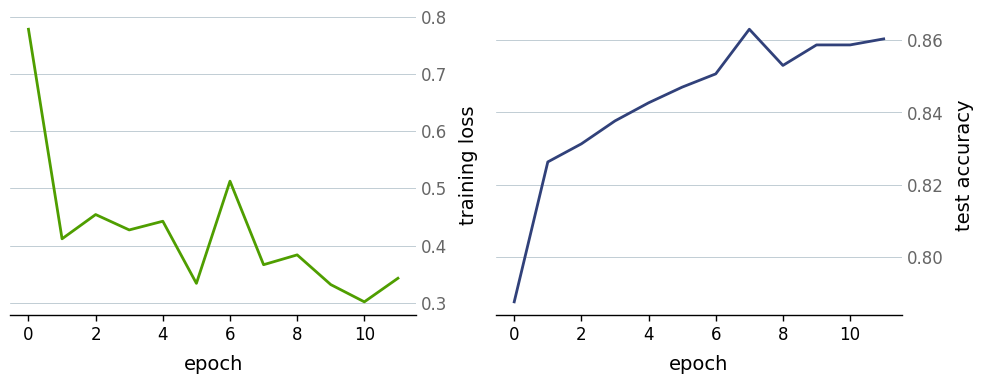

final test accuracy: 0.860


In [6]:
ep, tr_loss, te_acc = zip(*history)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4))
a1.plot(ep, tr_loss, color=mt.GREEN,   lw=2); a1.set_xlabel("epoch"); a1.set_ylabel("training loss")
a2.plot(ep, te_acc,  color=mt.FS_BLUE, lw=2); a2.set_xlabel("epoch"); a2.set_ylabel("test accuracy")
mt.apply_book_style(a1); mt.apply_book_style(a2)
fig.tight_layout()
plt.show()
print(f"final test accuracy: {te_acc[-1]:.3f}")

## What it gets right—and wrong

A couple of seconds of training reaches the high-80s in accuracy. Below are a few test images with the model's prediction (green if correct, red if not); the mistakes are revealing—shirts, coats, and pullovers are genuinely hard to tell apart at 28×28.

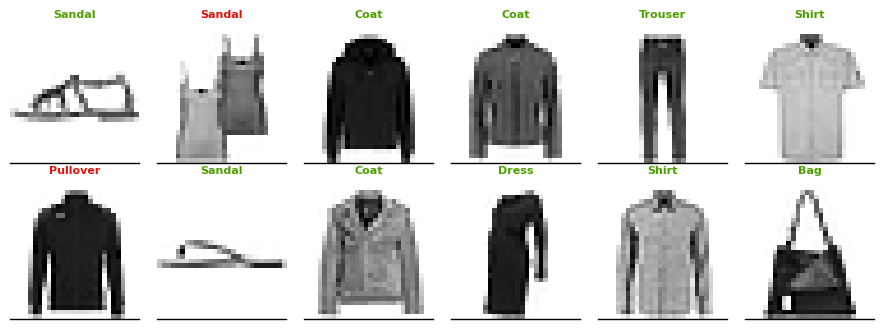

In [7]:
model.eval()
with torch.no_grad():
    preds = model(X_te[:12]).argmax(dim=1)
model.train()

fig, axes = plt.subplots(2, 6, figsize=(9, 3.4))
for ax, i in zip(axes.ravel(), range(12)):
    ax.imshow(X_te[i].reshape(28, 28), cmap="gray_r")
    correct = preds[i].item() == y_te[i].item()
    ax.set_title(classes[preds[i]], fontsize=8, color=(mt.GREEN if correct else mt.RED))
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

## Try next

- **Make it better.** Add a third hidden layer, change the width, or tune the dropout and learning rate. How far past the high-80s can a plain MLP push on this data?
- **What's missing.** The MLP treats the 784 pixels as an unordered list—it has no idea that two pixels are neighbors. Chapter 10 fixes exactly that with a *convolutional* network, on this same dataset and with this same training loop; only the model changes.
- **The thread.** Keep this loop in mind. In Chapter 12 it trains a GPT: the data and the model differ, but `zero_grad → backward → step` is identical. The capstone is this notebook, scaled up.